#  Titanic Survival Prediction

## Business Problem

The objective of this project is to build a machine learning model capable of predicting passenger survival aboard the Titanic based on demographic and travel-related information.

## Project Goals

Perform data cleaning and preprocessing

Conduct exploratory data analysis (EDA)

Engineer new predictive features

Build and optimize Decision Tree models

Apply pre-pruning and post-pruning techniques

Evaluate model performance using classification metrics

Generate a Kaggle submission file

## Описание набора данных
Обзор
Данные были разделены на две группы:

обучающий набор данных (train.csv)
набор тестов (test.csv)
Обучающий набор данных следует использовать для построения моделей машинного обучения. В качестве обучающего набора мы предоставляем результаты (также известные как «эталонные данные») для каждого пассажира. Ваша модель будет основана на «признаках», таких как пол и класс пассажиров. Вы также можете использовать инженерию признаков для создания новых признаков.

Тестовый набор данных следует использовать для оценки того, насколько хорошо ваша модель работает на неизвестных данных. Для тестового набора данных мы не предоставляем истинные значения для каждого пассажира. Ваша задача — предсказать эти результаты. Для каждого пассажира в тестовом наборе данных используйте обученную вами модель, чтобы предсказать, выжил ли он после крушения «Титаника».

В качестве примера того, как должен выглядеть файл для отправки данных, мы также включили файл gender_submission.csv , содержащий набор прогнозов, предполагающих, что выживут только все пассажирки женского пола.

## Словарь данных
Переменная	Определение	Ключ
выживание	Выживание	0 = Нет, 1 = Да

pclass	Класс билета	1 = 1-й, 2 = 2-й, 3 = 3-й

секс	Секс

Возраст	Возраст в годах

сибсп	Количество братьев и сестер/супругов на борту «Титаника»

царская	Количество родителей/детей на борту «Титаника»

билет	Номер билета

тариф	Стоимость проезда пассажира

кабина	Номер каюты

отправился в путь	Порт отправления	C = Шербур, Q = Куинстаун, S = Саутгемптон

**Переменные примечания**

pclass : Показатель социально-экономического статуса (СЭС).

1-й = Высший

, 2-й = Средний

, 3-й = Низший.

age : Возраст является дробным, если он меньше 1.

Если возраст оценивается, он имеет вид xx.5.

sibsp : В наборе данных семейные отношения определяются следующим образом...

Sibling = брат, сестра,
сводный брат, сводная сестра.

Spouse = муж, жена (любовницы и женихи не учитывались).

parch : В наборе данных семейные отношения определяются следующим образом...

Parent = мать, отец.

Child = дочь, сын, падчерица, пасынок.

Некоторые дети путешествовали только с няней, поэтому для них parch=0.

# 0. Imports

In [ ]:
import pandas as pd              # pandas — работа с таблицами (DataFrame)
import numpy as np               # numpy — работа с массивами и числами

import matplotlib.pyplot as plt  # matplotlib — базовые графики
import seaborn as sns            # seaborn — красивые статистические графики

from sklearn.model_selection import train_test_split          # разбиение на train/test
from sklearn.tree import DecisionTreeClassifier, plot_tree    # дерево решений и его визуализация
from sklearn.metrics import (
    accuracy_score,              # Accuracy (точность по всем классам)
    precision_score,             # Precision (точность)
    recall_score,                # Recall (полнота)
    f1_score,                    # F1-score
    classification_report,       # подробный отчёт по классам
    confusion_matrix             # confusion matrix (матрица ошибок)
)


# 1. Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After running the above cell and following the prompts to authorize access,
# your Google Drive will be mounted at '/content/drive'.
# You can then access your files using paths like this:
# '/content/drive/MyDrive/Your_Folder/your_file.csv'
# or
# '/content/drive/Shareddrives/Your_Shared_Drive/Your_Folder/your_file.csv'

# Example: If 'train.csv' is in a folder named 'TitanicData' in your MyDrive:
# file_path_train = '/content/drive/MyDrive/TitanicData/train.csv'
# df_train = pd.read_csv(file_path_train)
# print(df_train.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Replace 'Your_Folder/your_file.csv' with the actual path to your CSV file on Google Drive
# For example, if your file is in 'MyDrive/Data/train.csv', the path would be '/content/drive/MyDrive/Data/train.csv'
drive_file_path = '/content/drive/MyDrive/Colab Notebooks/Predictive Modeling with Linear Regression/titanic/train.csv'
drive_file_path_test = '/content/drive/MyDrive/Colab Notebooks/Predictive Modeling with Linear Regression/titanic/test.csv'

try:
    train_data = pd.read_csv(drive_file_path)
    test_data = pd.read_csv(drive_file_path_test)
    print("Successfully loaded data from Google Drive!")
    display(train_data.head(10))
except FileNotFoundError:
    print(f"Error: The file '{drive_file_path}' or '{drive_file_path_test}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from Google Drive!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
print(train_data.shape)
train_data.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## DATA PREPROCESSING

##  Step 1. Remove the Cabin Column

In [ ]:
train_data = train_data.drop(columns=['Cabin'])
test_data = test_data.drop(columns=['Cabin'])


## Step 2. Fill Missing Values in Age Using the Median

In [ ]:
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())


## Step 3. Fill Missing Values in Embarked Using the Mode

In [ ]:
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])


## Step 4. Fill Missing Fare Values in the Test Dataset

In [ ]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())


## Step 5. Convert Categorical Features to Category Type

In [ ]:
categorical_cols = ['Sex', 'Embarked', 'Pclass']
for col in categorical_cols:
    train_data[col] = train_data[col].astype('category')
    test_data[col] = test_data[col].astype('category')

## Step 6. Save PassengerId for Final Submission

In [ ]:
test_ids = test_data['PassengerId']


## Step 7. Remove PassengerId from the Modeling Dataset

In [ ]:
train_data = train_data.drop(columns=['PassengerId'], errors='ignore')
test_data = test_data.drop(columns=['PassengerId'], errors='ignore')

## Step 8. Remove Name and Ticket Features

In [ ]:
train_data = train_data.drop(columns=['Name', 'Ticket'])
test_data = test_data.drop(columns=['Name', 'Ticket'])


** The drop(columns=[...]) function removes the specified columns from the dataset.

The same transformation is applied to both training and testing datasets to ensure consistency.

The Name and Ticket features were removed because they are unlikely to provide meaningful predictive value and are not required for exploratory analysis or model training.

## Step 9. Remove Duplicate Records

In [ ]:
# 11. Проверяем дубликаты
train_data = train_data.drop_duplicates()

DESCRIPTIVE STATISTICS

In [ ]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,775.0,0.412903,0.492674,0.00,0.00,0.0,1.0000,1.0000
Age,775.0,29.581187,13.766359,0.42,21.00,28.0,36.0000,80.0000
SibSp,775.0,0.529032,0.990326,0.00,0.00,0.0,1.0000,8.0000
Parch,775.0,0.420645,0.840565,0.00,0.00,0.0,1.0000,6.0000
Fare,775.0,34.878403,52.408474,0.00,8.05,15.9,34.1979,512.3292


In [ ]:
train_data.sum(numeric_only=True)

,0
Survived,320.0000
Age,22925.4200
SibSp,410.0000
Parch,326.0000
Fare,27030.7623


## **Summary Statistics**

The dataset contains 775 unique passenger records after duplicate removal.

The average passenger age is approximately 29.6 years.

The average fare is 34.88.

The target variable indicates that approximately 41.3% of passengers survived, while 58.7% did not survive.

The Fare variable contains substantial variability and several extreme values.

# Exploratory Data Analysis (EDA)

## Univariate Exploratory Data Analysis

## 1. Step 1. Separate Numerical and Categorical Features

In [ ]:
numeric_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_data.select_dtypes(include=['category', 'object']).columns
print(numeric_cols
)
print(categorical_cols)


Index(['Survived', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Index(['Pclass', 'Sex', 'Embarked'], dtype='object')


## Step 2. Univariate Analysis of Numerical Features

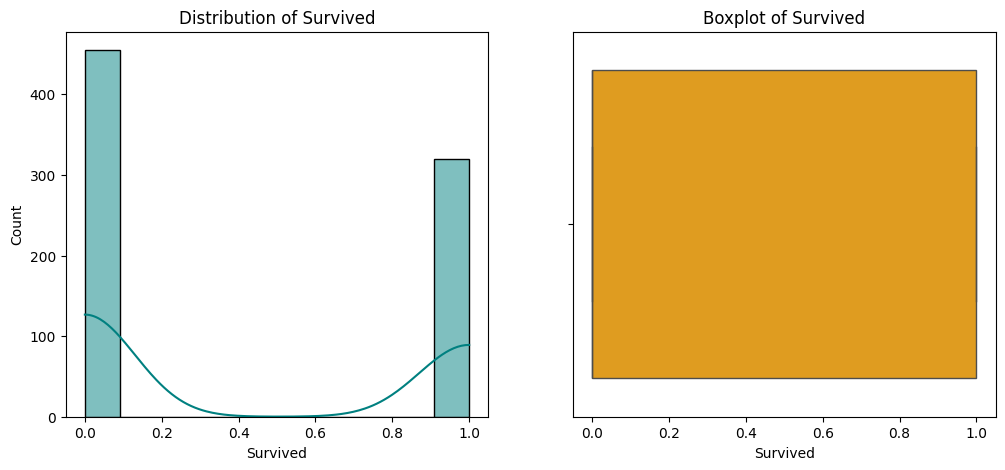

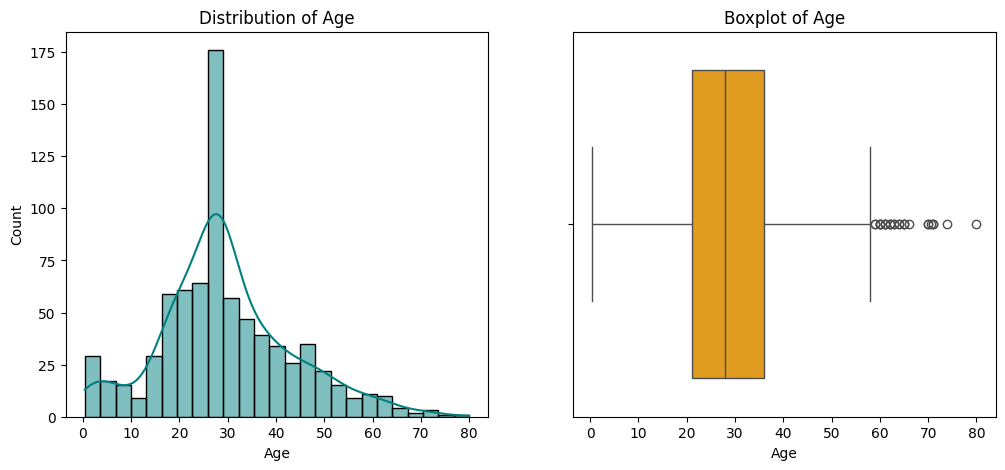

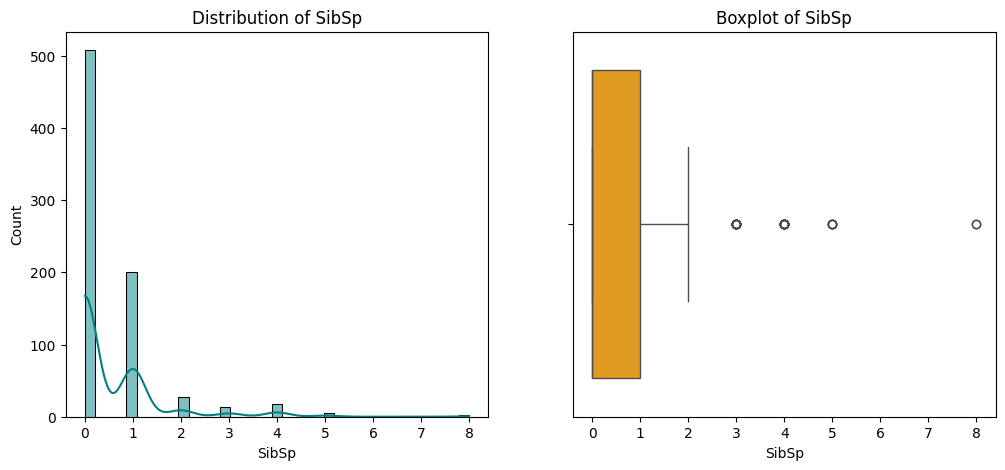

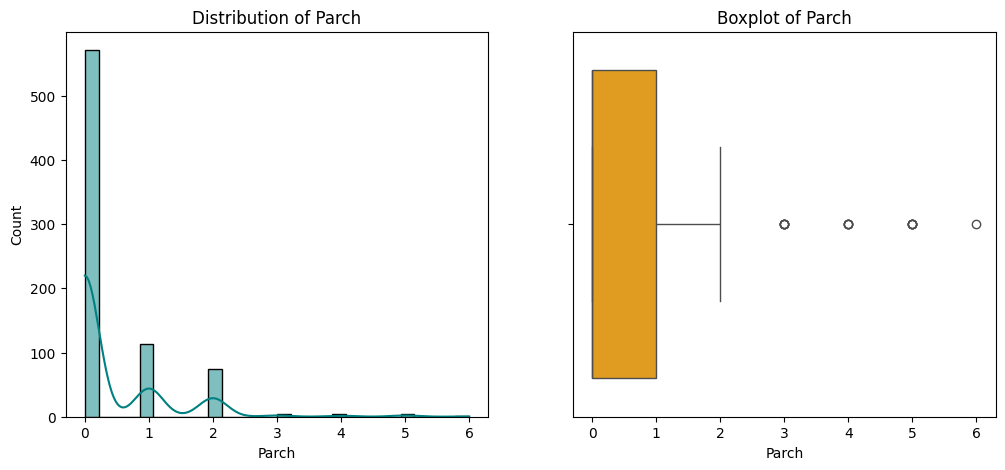

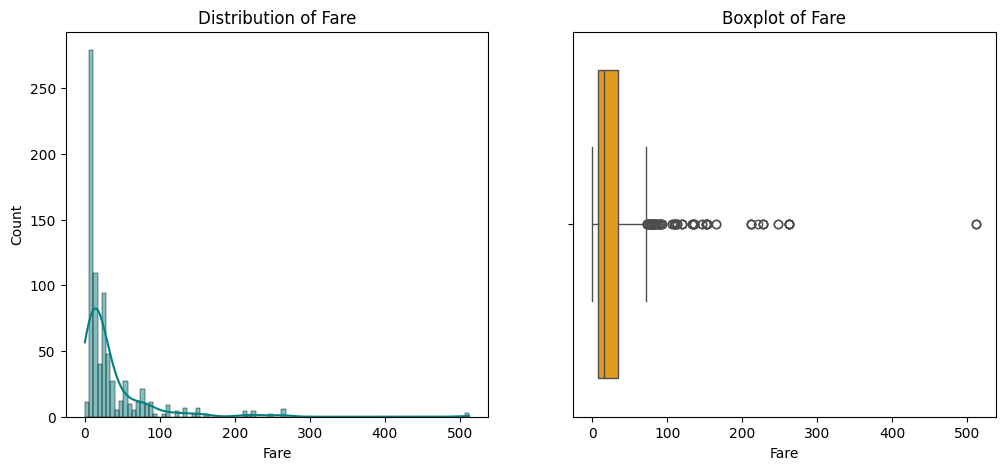

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(12, 5))

    # Гистограмма
    plt.subplot(1, 2, 1)
    sns.histplot(train_data[col], kde=True, color='teal')
    plt.title(f"Distribution of {col}")

    # Боксплот
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_data[col], color='orange')
    plt.title(f"Boxplot of {col}")

    plt.show()


**Age** displays a slightly right-skewed distribution.

**Fare** exhibits strong positive skewness and contains multiple outliers.

**SibSp and Parch** contain a large number of zero values with a few extreme observations.

**These observations help identify features that may benefit from transformation, normalization, or outlier treatment.**

## CATEGORICAL ANALYSIS

## Step 3. Univariate Analysis of Categorical Features

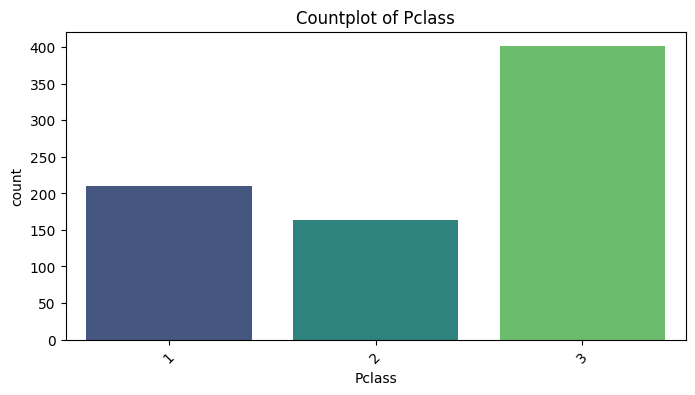

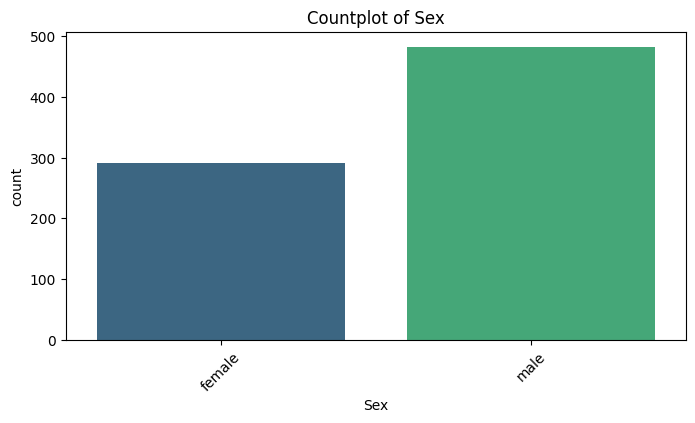

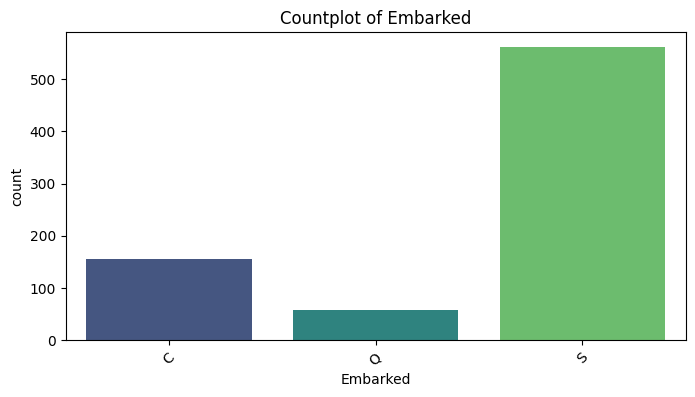

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=train_data[col], hue=train_data[col], palette='viridis', legend=False)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

## **Key Observations:**
There are more male passengers than female passengers in the dataset.

Most passengers embarked from **Southampton **(S).

Third-class passengers represent the largest group in the dataset.

👉 These distributions help identify potential category imbalances that may influence model performance.

## SUMMARY STATISTICS

## Step 4. Summary Statistics for Numerical Features

In [ ]:
train_data[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Survived,775.0,0.412903,0.492674,0.00,0.00,0.0,1.0000,1.0000
Age,775.0,29.581187,13.766359,0.42,21.00,28.0,36.0000,80.0000
SibSp,775.0,0.529032,0.990326,0.00,0.00,0.0,1.0000,8.0000
Parch,775.0,0.420645,0.840565,0.00,0.00,0.0,1.0000,6.0000
Fare,775.0,34.878403,52.408474,0.00,8.05,15.9,34.1979,512.3292


**The describe() function provides:**

• Mean

• Median

• Minimum

• Maximum

• Standard Deviation

• Quartiles

👉 This provides a quick overview of the scale, central tendency, and variability of each feature.

## SKEWNESS

## 5. Step 5. Evaluate Feature Skewness

In [ ]:
train_data[numeric_cols].skew()


,0
Survived,0.354483
Age,0.441987
SibSp,3.036078
Parch,2.613347
Fare,4.549950


**Skewness measures the asymmetry of a distribution.**

Values greater than 1 indicate strong skewness.

The Fare feature exhibits substantial positive skewness with a value exceeding 4.

👉 Understanding skewness is important when working with algorithms that are sensitive to feature distributions.

## Bivariate EDA

**Relationship Between Features and Survival**

This is one of the most important stages of the Titanic project.


How each feature influences the probability of survival

Which features are strong predictors

Which features have weak predictive power

Which features should be retained for modeling

## BIVARIATE CATEGORICAL ANALYSIS

## Step 1. Relationship Between Categorical Features and Survival

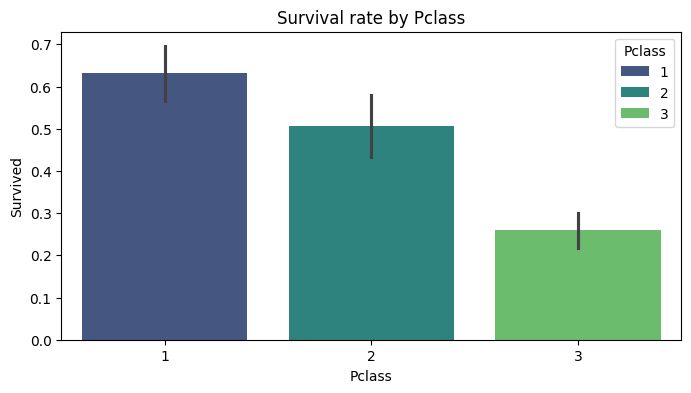

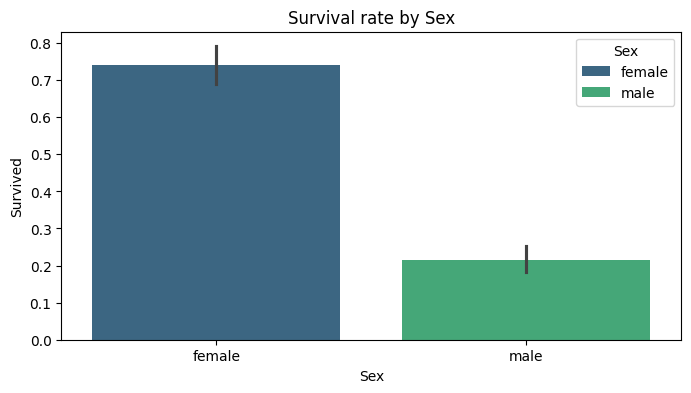

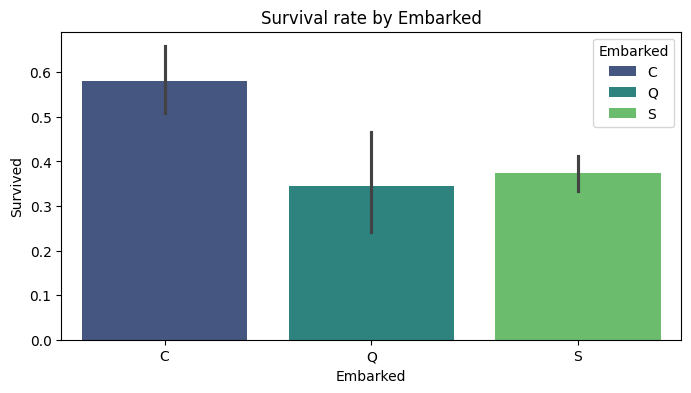

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=train_data[col], y=train_data['Survived'], hue=train_data[col], palette='viridis', legend=True)
    plt.title(f"Survival rate by {col}")
    plt.show()

**Key Findings**

**Female passengers** had a significantly higher survival rate than male passengers.

**First-class passengers** had a substantially higher survival rate than third-class passengers.

**Passengers embarking from Southampton (S)** exhibited lower survival rates compared to other embarkation ports.

👉 These relationships help identify the most influential predictors of survival.

## Survival Rate Analysis

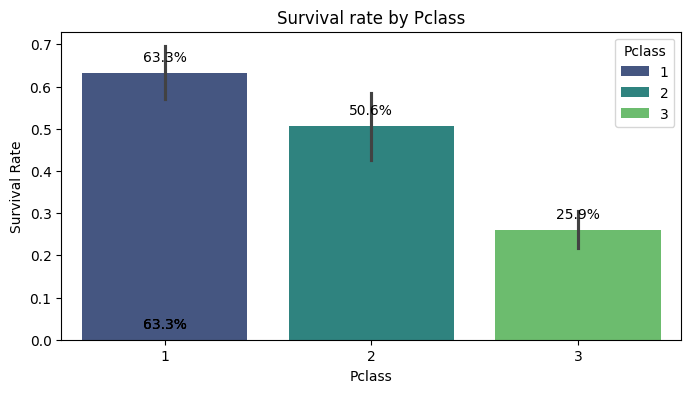

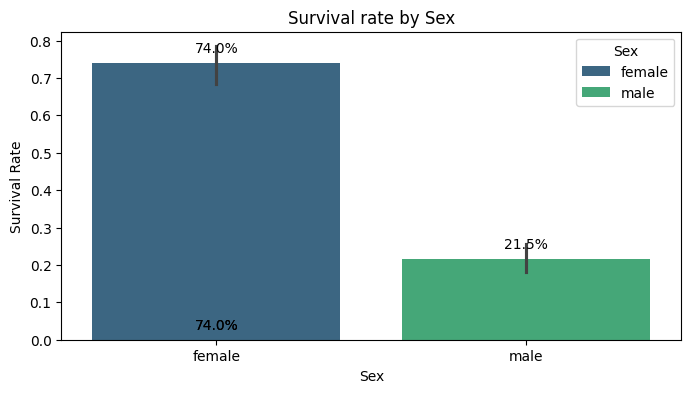

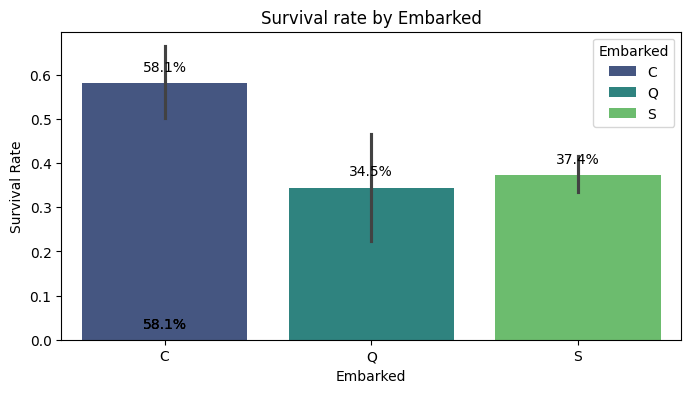

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=train_data[col], y=train_data['Survived'], hue=train_data[col], palette='viridis', legend=True)
    plt.title(f"Survival rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Survival Rate")

    # Calculate survival rates for annotation
    # Use observed=False to include all categories, even if not present in current data subset (to avoid FutureWarning)
    survival_rates = train_data.groupby(col, observed=False)['Survived'].mean() * 100

    # Annotate bars with percentages
    # Get the unique categories directly from the column's categorical type
    categories_in_col = train_data[col].cat.categories

    # Iterate through patches (bars) to annotate
    for patch_idx, patch in enumerate(ax.patches):
        # Determine which category this patch belongs to based on its x-position
        # The x-coordinates of bars typically correspond to the numerical index of categories (0, 1, 2, ...)
        # Rounding the center of the bar's x-coordinate usually gives this index.
        try:
            # Calculate the numerical index of the category from the patch's position
            category_numerical_idx = int(round(patch.get_x() + patch.get_width() / 2.0))

            # Get the actual category name using this numerical index
            # Ensure the index is within the bounds of categories_in_col
            if 0 <= category_numerical_idx < len(categories_in_col):
                category_name_str = str(categories_in_col[category_numerical_idx])
            else:
                # Fallback if index is out of expected range (should not happen with this approach normally)
                print(f"Warning: Category index {category_numerical_idx} out of bounds for column {col}. Skipping annotation for this patch.")
                continue

            # Convert category_name to the appropriate type to match the index of survival_rates
            if col == 'Pclass':
                category_name_for_lookup = int(category_name_str)
            else:
                category_name_for_lookup = category_name_str

            # Get the survival rate for this category
            percentage = survival_rates.loc[category_name_for_lookup]

            # Add the text label slightly above the bar
            ax.text(patch.get_x() + patch.get_width() / 2.,
                    patch.get_height() + 0.02, # Adjust vertical position
                    f'{percentage:.1f}%',
                    ha='center', va='bottom', fontsize=10, color='black')
        except (IndexError, KeyError) as e:
            print(f"Error annotating patch {patch_idx} for column {col}: {e}. Skipping this annotation.")
            continue

    plt.show()

### Посчитаю, сколько всего выжило в процентном соотношении

In [ ]:
survived_percentage = train_data['Survived'].value_counts(normalize=True) * 100
print("Процентное соотношение выживших:")
print(survived_percentage)

Процентное соотношение выживших:
Survived
0    58.709677
1    41.290323
Name: proportion, dtype: float64


**Survival Distribution**

The target variable is moderately imbalanced.

Approximately 41% of passengers survived, while 59% did not survive.

This class distribution should be considered during model evaluation, particularly when interpreting precision, recall, and F1-score.

## 2. Relationship Between Numerical Features and Survival

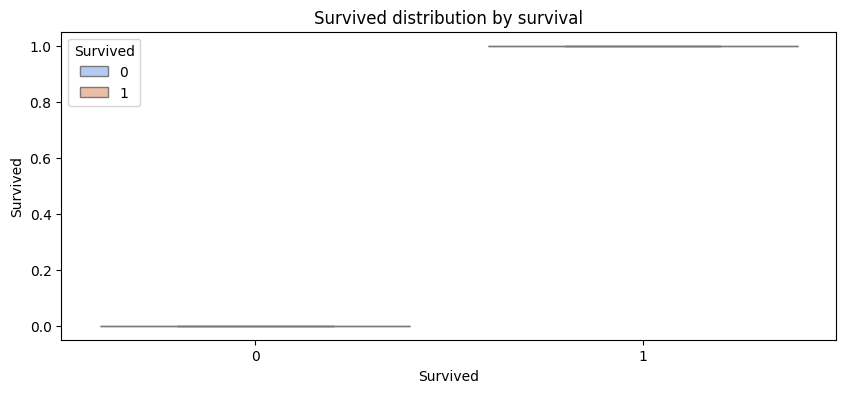

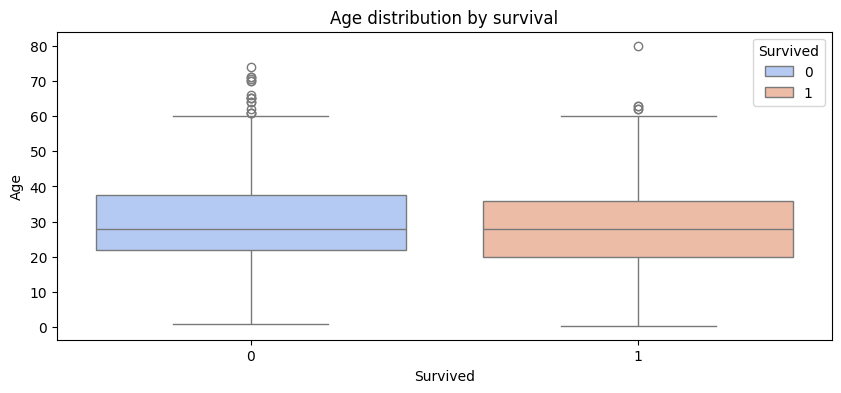

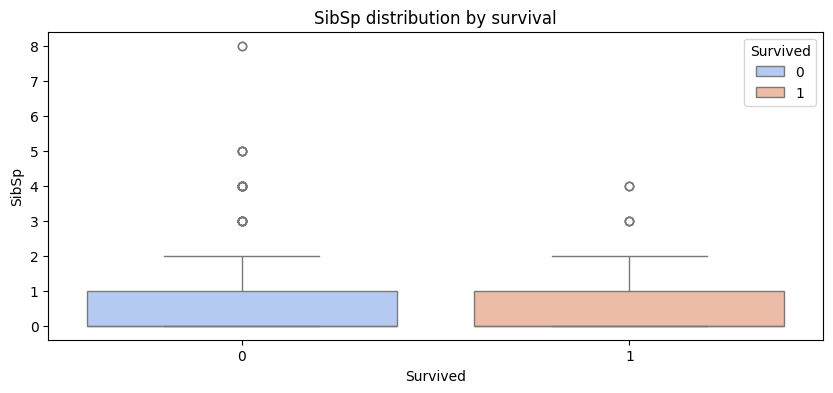

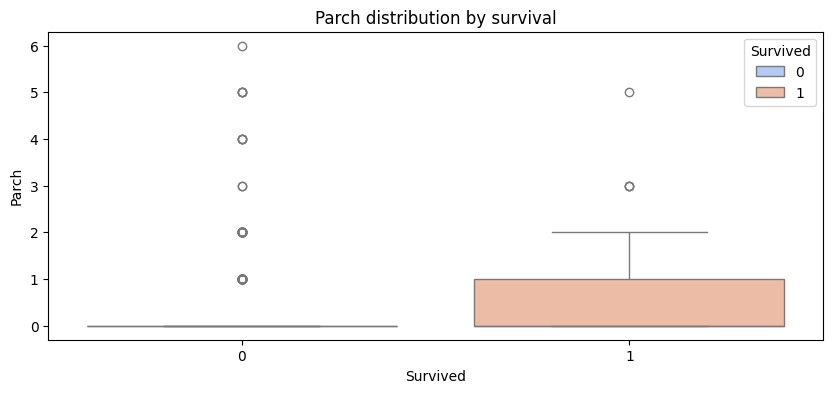

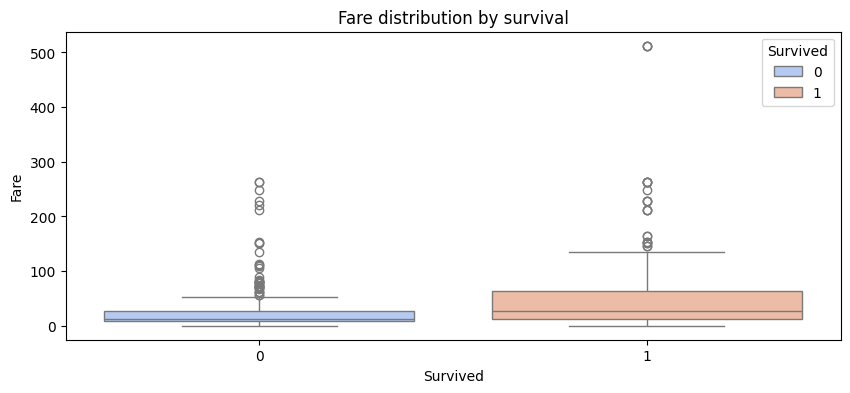

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=train_data['Survived'], y=train_data[col], hue=train_data['Survived'], palette='coolwarm', legend = True)
    plt.title(f"{col} distribution by survival")
    plt.show()

Passengers who survived generally paid higher fares than those who did not survive.

Children exhibited higher survival rates compared to adult passengers.

Passengers aged over 60 demonstrated lower survival rates.

## 3. Correlation Analysis

The correlation heatmap highlights relationships among numerical variables.

It helps identify potential multicollinearity issues.

It also supports feature selection and model interpretation.

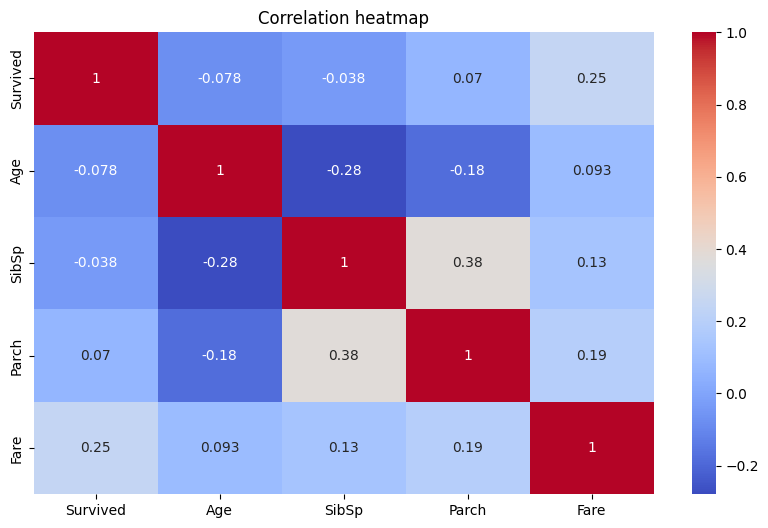

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

### Correlation Analysis Findings

The correlation matrix revealed that:


• Fare shows a moderate relationship with passenger class.


• SibSp and Parch exhibit only weak correlations with survival.


• No significant multicollinearity was observed among numerical variables.


These results suggest that most features contribute unique information to the model.


## 1. Univariate Analysis
We examined the distribution of each numerical and categorical feature individually.

Numerical features (Age, Fare, SibSp, Parch) showed strong skewness and the presence of outliers, especially in Fare.

Categorical features (Sex, Pclass, Embarked) demonstrated clear imbalance: most passengers were male, embarked from port S, and traveled in 3rd class.

This analysis helped identify potential transformations (e.g., log-transform for Fare) and understand the structure of the dataset.

## 2. Bivariate Analysis
We analyzed how each feature relates to the target variable Survived.

Categorical Features
Barplots with survival percentages revealed strong patterns:

Sex: Females had a significantly higher survival rate (~74%) compared to males (~19%).

Pclass: Passengers in 1st class survived much more frequently than those in 3rd class.

Embarked: Passengers from port C had the highest survival rate, while those from S had the lowest.

These findings indicate that gender, class, and port of embarkation are strong predictors of survival.

Numerical Features
Boxplots showed:

Survivors tended to have higher Fare, indicating a link between ticket price and survival.

Age distribution differed slightly: children had higher survival rates.

SibSp and Parch showed that passengers traveling with family had a slightly higher chance of survival.

## 3. Correlation Analysis
A heatmap of numerical correlations showed:

Fare correlates moderately with Pclass.

SibSp and Parch correlate weakly with Survived.

No harmful multicollinearity among numerical features.

## Conclusion
EDA revealed that the most influential predictors are:

Sex

Pclass

Fare

Embarked

Age

These insights guide the next step: Feature Engineering.

# Feature Engineering

## FamilySize

In [ ]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1




A new feature, FamilySize, was created by combining SibSp and Parch.


This feature represents the total number of family members traveling together.


Previous exploratory analysis suggested that passengers traveling with family often had higher survival rates than those traveling alone.

## IsAlone

In [ ]:
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)


The IsAlone feature identifies passengers traveling without family members.


Exploratory analysis indicated that solo travelers generally experienced lower survival rates compared to passengers traveling with family members.

## FarePerPerson (цена билета на человека)

In [ ]:
train_data['FarePerPerson'] = train_data['Fare'] / train_data['FamilySize']
test_data['FarePerPerson'] = test_data['Fare'] / test_data['FamilySize']


The FarePerPerson feature was created by dividing ticket fare by family size.


This variable may provide a more accurate representation of individual socioeconomic status than the original Fare feature.

# Decision Tree

## 2.1. Define Features and Target Variable

In [ ]:
y = train_data['Survived']
X = train_data.drop(columns=['Survived'])


## 2.2. One-Hot Encoding

In [ ]:
X = pd.get_dummies(X, drop_first=True)


## Split Data into Training and Validation Sets

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train the Initial Decision Tree Model

The initial Decision Tree model was evaluated using several classification metrics:

• Accuracy

• Precision

• Recall

• F1-Score

• Confusion Matrix

• Classification Report

These metrics provide a comprehensive assessment of model performance beyond simple accuracy.

## 1. Decision Tree Model

In [ ]:
tree_clf = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


## 2. Training

In [ ]:
tree_clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

## Делаем предсказания и считаем качество (только для предсказанных данных)

In [ ]:
# 1. Делаем предсказания на валидационных данных
y_pred = tree_clf.predict(X_valid)

# 2. Accuracy — доля правильных ответов
acc = accuracy_score(y_valid, y_pred)

# 3. Precision — точность (как мало ложных срабатываний)
prec = precision_score(y_valid, y_pred)

# 4. Recall — полнота (как мало пропущенных выживших)
rec = recall_score(y_valid, y_pred)

# 5. F1-score — баланс между precision и recall
f1 = f1_score(y_valid, y_pred)

# 6. Матрица ошибок
cm = confusion_matrix(y_valid, y_pred)

# 7. Подробный отчёт
report = classification_report(y_valid, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Accuracy: 0.7483870967741936
Precision: 0.6923076923076923
Recall: 0.703125
F1-score: 0.6976744186046512

Confusion Matrix:
 [[71 20]
 [19 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78        91
           1       0.69      0.70      0.70        64

    accuracy                           0.75       155
   macro avg       0.74      0.74      0.74       155
weighted avg       0.75      0.75      0.75       155



## Confusion Matrix

### Understanding the Confusion Matrix


The confusion matrix allows us to visualize where the model makes correct and incorrect predictions.


It summarizes:


• Correctly predicted non-survivors (True Negatives)


• Correctly predicted survivors (True Positives)


• False Positives


• False Negatives

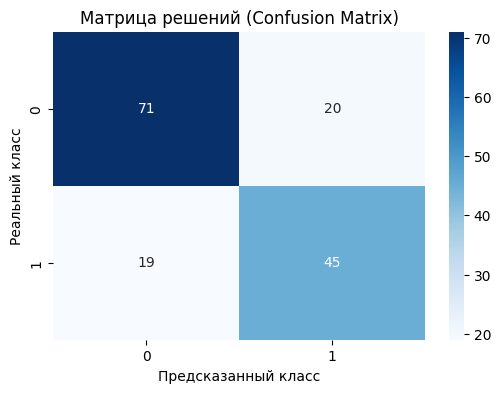

In [ ]:


# Строим матрицу ошибок


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Матрица решений (Confusion Matrix)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Реальный класс")
plt.show()


TN — правильно сказали «не выжил»

TP — правильно сказали «выжил»

FP — модель ошиблась: сказала «выжил», но человек не выжил

FN — модель ошиблась: сказала «не выжил», но человек выжил

Accuracy measures the percentage of correct predictions.

Precision measures how many predicted survivors actually survived.

Recall measures how many actual survivors were correctly identified by the model.

F1-score provides a balance between Precision and Recall.

### Initial Decision Tree Results

The baseline Decision Tree achieved reasonable predictive performance.


However, the unrestricted tree appears susceptible to overfitting, capturing patterns that may not generalize well to unseen data.


The confusion matrix shows that the model makes more mistakes when predicting the Survived class, which is common in moderately imbalanced datasets.


To improve generalization and reduce overfitting, pre-pruning techniques will be applied in the next stage of the analysis.

## Pre-Pruning the Decision Tree

| Parameter | Description |
| --- | --- |
| **max_depth** | Maximum depth of the tree |
| **min_samples_split** | Minimum number of samples required to split a node |
| **min_samples_leaf** | Minimum number of samples required in a leaf node |
| **max_leaf_nodes** | Maximum number of leaf nodes |

In [ ]:
tree_clf_pruned = DecisionTreeClassifier(
    max_depth=4,            # ограничиваем глубину
    min_samples_split=10,   # минимум 10 объектов для разбиения
    min_samples_leaf=5,     # минимум 5 объектов в листе
    random_state=42
)

tree_clf_pruned.fit(X_train, y_train)

y_pred_pruned = tree_clf_pruned.predict(X_valid)

print("Accuracy (pruned):", accuracy_score(y_valid, y_pred_pruned))


Accuracy (pruned): 0.8064516129032258


### Pre-Pruning Results

After applying pre-pruning constraints, the model became more stable and less prone to overfitting.


The confusion matrix indicates a reduction in classification errors, particularly False Positives and False Negatives.


Performance metrics improved, especially Recall and F1-score, which are critical for identifying surviving passengers.


Overall, the pruned model is simpler, more interpretable, and better suited for making predictions on unseen data.

## Evaluate the Pre-Pruned Model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics_table = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Значение': [
        accuracy_score(y_valid, y_pred_pruned),
        precision_score(y_valid, y_pred_pruned),
        recall_score(y_valid, y_pred_pruned),
        f1_score(y_valid, y_pred_pruned)
    ]
})

metrics_table


,Метрика,Значение
0,Accuracy,0.806452
1,Precision,0.757576
2,Recall,0.781250
3,F1-score,0.769231


## Confusion Matrix for the Pre-Pruned Model

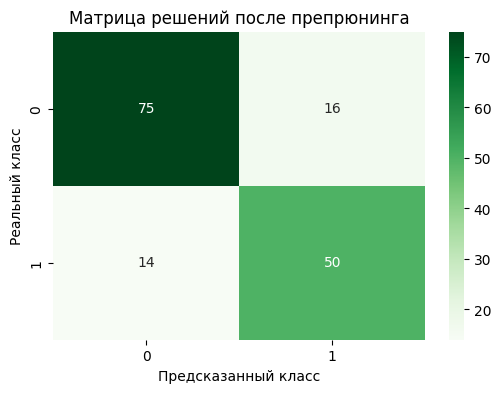

In [ ]:
cm_pruned = confusion_matrix(y_valid, y_pred_pruned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Pre-Pruned Decision Tree")
plt.xlabel("Предсказанный класс")
plt.ylabel("Реальный класс")
plt.show()


### Pre-Pruning Results
After applying pre-pruning constraints, the Decision Tree became more stable and less prone to overfitting.

The confusion matrix indicates a reduction in classification errors, particularly False Positives and False Negatives.

Model performance improved across several evaluation metrics, especially Recall and F1-score, which are critical for identifying surviving passengers.

Overall, pre-pruning produced a simpler, more interpretable model that is likely to generalize better to unseen data.

TREE VISUALIZATION

## Decision Tree Visualization

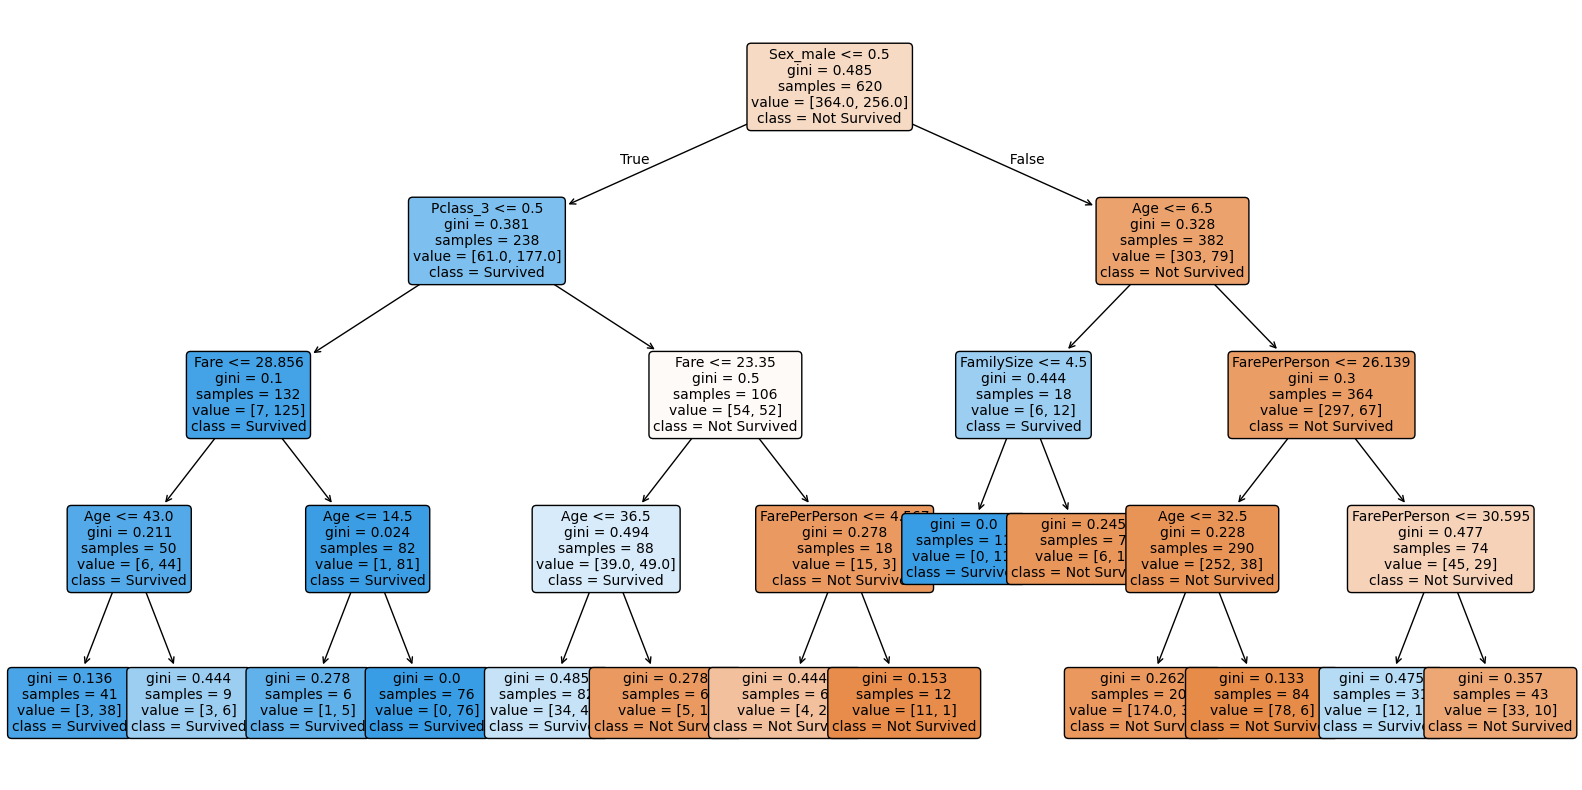

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_clf_pruned,
    feature_names=X_train.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()


**Visualization Explanation:**

plt.figure(figsize=(20, 10))  
Create a large figure to visualize the complete tree structure.

plot_tree(...)  
**Visualize the trained Decision Tree model.:**

tree_clf_pruned — наша модель.

feature_names=X_train.columns — подписываем, по каким признакам делим.

class_names=['Not Survived', 'Survived'] — подписи классов.

filled=True — раскрашиваем узлы по классу.

rounded=True — делаем узлы с закруглёнными углами.

fontsize=10 — размер текста.

plt.show()  
Display the final visualization.

## FEATURE IMPORTANCE

## 2. Feature Importance Analysis

In [ ]:
import pandas as pd

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree_clf_pruned.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by='Importance',
    ascending=False
)

feature_importances


,Признак,Важность
9,Sex_male,0.577364
8,Pclass_3,0.167274
6,FarePerPerson,0.093807
0,Age,0.082625
4,FamilySize,0.042929
3,Fare,0.036001
2,Parch,0.000000
1,SibSp,0.000000
7,Pclass_2,0.000000
5,IsAlone,0.000000


tree_clf_pruned.**feature_importances_ **
The feature_importances_ attribute returns a numerical importance score for each feature used by the model.**

**A DataFrame is created to organize feature names and their corresponding importance values.:**

Признак — имя признака.

Важность — его важность.

sort_values(..., **ascending=False)**  
Features are sorted in descending order of importance.

## FEATURE IMPORTANCE PLOT

## Visualizing Feature Importance

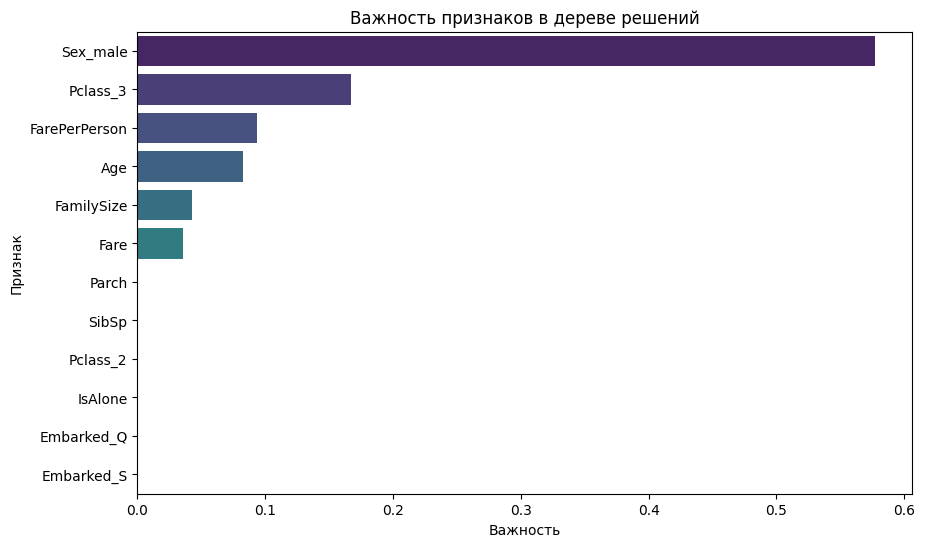

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importances,
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

sns.barplot — **A horizontal bar chart is used to visualize feature importance rankings..**

plt.xlabel("Importance")

plt.ylabel("Feature")

**Longer bars indicate features that contribute more to model predictions..**

Most Important Predictors of Survival

**The most influential features typically include::**

• Sex

• Passenger Class

• Fare

• Age

• Embarkation Port

• Family-Based Features

### Feature Importance Conclusions
The Decision Tree visualization reveals the sequence of rules used to predict passenger survival.

The top levels of the tree primarily rely on features related to gender, passenger class, and fare, highlighting their predictive power.

Feature importance analysis confirms that variables associated with social status and gender contribute most strongly to survival prediction.

These findings are consistent with historical accounts of the Titanic disaster, where women and first-class passengers had substantially higher survival rates.

One of the key advantages of Decision Trees is interpretability, allowing us to understand which factors drive predictions and build trust in the model.

### Why Was Embarked Not Identified as an Important Feature?

Although embarkation port showed differences in survival rates during exploratory analysis, it was not selected as a major predictor by the Decision Tree.

This can occur because Embarked provides less predictive information than stronger variables such as Sex, Pclass, and Fare.

Additionally, Embarked is partially correlated with other features. Since Decision Trees prioritize the most informative splits, weaker correlated variables may receive little or no importance.

This does not imply that Embarked has no relationship with survival. Rather, its predictive information is already captured by stronger features in the model.



### GRIDSEARCHCV

### Hyperparameter Optimization Using GridSearchCV

### 1. Step 1. Import GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

GridSearchCV systematically evaluates multiple hyperparameter combinations and identifies the configuration that produces the best model performance.

### Step 2. Define the Hyperparameter Search Grid

In [ ]:
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}


### Step 3. Create the Base Decision Tree Model

In [ ]:
base_tree = DecisionTreeClassifier(random_state=42)


## Step 4. Configure GridSearchCV

In [ ]:
grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring='f1',      # можно 'accuracy', но F1 лучше при несбалансированных классах
    cv=5,              # 5-кратная кросс-валидация
    n_jobs=-1,         # использовать все ядра процессора
    verbose=1          # печатать прогресс
)


estimator=base_tree — какую модель настраиваем.

param_grid=param_grid — какие параметры перебираем.

scoring='f1' — по какой метрике выбираем лучшую модель.

cv=5 — делим данные на 5 частей, по очереди обучаем/проверяем.

n_jobs=-1 — использовать все ресурсы (ускоряет).

verbose=1 — показывать прогресс.

## Step 5. Perform Hyperparameter Search

In [ ]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=1)

**The model is trained multiple times using different hyperparameter combinations.**

For each parameter combination, the average F1-score is calculated using cross-validation.

At the end of the search, GridSearchCV automatically stores the best-performing model.

### BEST PARAMETERS

### Step 6. Review the Best Hyperparameters

In [ ]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Average F1:", grid_search.best_score_)


Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучший F1-score: 0.7467421236535852


## Best Hyperparameter Configuration

The optimal Decision Tree configuration identified by GridSearchCV was:

• max_depth = 3

• min_samples_leaf = 5

• min_samples_split = 2

This configuration achieved the highest average F1-score during cross-validation, indicating the best balance between bias and variance.

### GRID SEARCH RESULTS

# Step 7. Analyze Grid Search Results

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

# Оставим только важные колонки
results_table = results[[
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score'
]].sort_values(by='mean_test_score', ascending=False)

results_table.head(10)


,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score
26,3,10,5,0.746742,0.027273
24,3,2,5,0.746742,0.027273
25,3,5,5,0.746742,0.027273
21,3,5,2,0.745110,0.024654
22,3,10,2,0.745110,0.024654
20,3,2,2,0.745110,0.024654
55,5,20,2,0.740118,0.043900
51,5,20,1,0.739925,0.050981
18,3,10,1,0.739814,0.027388
17,3,5,1,0.739814,0.027388


**The cv_results_ attribute** contains detailed results for every evaluated hyperparameter combination.

The results are converted into a DataFrame for easier analysis and comparison.

### We focus on key parameters, mean cross-validation F1-score, and score variability.

Results are sorted by **F1-score from highest to lowest.**

The top-performing parameter combinations are displayed for review.

## BEST MODEL EVALUATION

Step 8. Evaluate the Best GridSearchCV Model

In [ ]:
best_tree = grid_search.best_estimator_

y_pred_best = best_tree.predict(X_valid)

acc = accuracy_score(y_valid, y_pred_best)
prec = precision_score(y_valid, y_pred_best)
rec = recall_score(y_valid, y_pred_best)
f1 = f1_score(y_valid, y_pred_best)

metrics_table_best = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Значение': [acc, prec, rec, f1]
})

metrics_table_best


,Метрика,Значение
0,Accuracy,0.800000
1,Precision,0.811321
2,Recall,0.671875
3,F1-score,0.735043


## GridSearchCV Model Performance

The optimized Decision Tree achieved:

• Accuracy: 0.800

• Precision: 0.811

• Recall: 0.672

• F1-score: 0.735

The model demonstrates strong predictive precision while maintaining reasonable recall performance.

### CONFUSION MATRIX

### Step 9. Confusion Matrix for the Optimized Model

 The confusion matrix helps identify where the optimized model makes correct and incorrect predictions.

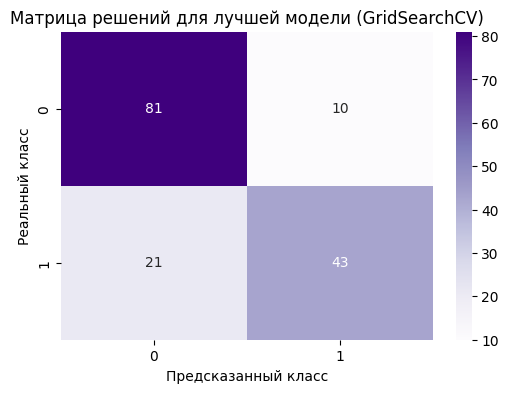

In [ ]:
cm_best = confusion_matrix(y_valid, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Purples')

plt.title("Confusion Matrix - GridSearchCV Decision Tree")
plt.xlabel("Предсказанный класс")
plt.ylabel("Реальный класс")
plt.show()


### GridSearchCV Conclusions

GridSearchCV systematically evaluated multiple hyperparameter combinations and selected the model with the highest cross-validated F1-score.

The optimized Decision Tree achieved improved generalization performance compared to the baseline model.

The confusion matrix indicates a reduction in prediction errors while maintaining strong classification performance.

Hyperparameter tuning helped identify a balanced model that avoids both excessive overfitting and underfitting.

## POST-PRUNING

## Post-Pruning Using Cost Complexity Pruning

In Scikit-Learn, post-pruning is performed using Cost Complexity Pruning (CCP).

### CCP ALPHA

Step 1. Generate the Cost Complexity Pruning Path

In [ ]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas      # значения альфа (степень обрезки)
impurities = path.impurities      # соответствующие значения "стоимости"


cost_complexity_pruning_path  

The cost complexity pruning path evaluates how model complexity changes as pruning strength increases.

ccp_alphas — список значений α (альфа).

Higher alpha values result in more aggressive pruning and simpler tree structures.

TRAIN MULTIPLE TREES

## Step 2. Train Multiple Trees with Different Alpha Values

In [ ]:
trees = []

for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=ccp_alpha
    )
    clf.fit(X_train, y_train)
    trees.append(clf)


В цикле перебираем **все значения ccp_alpha.**

A separate Decision Tree model is trained for each ccp_alpha value.

All trained models are stored for further evaluation.

## VALIDATION ANALYSIS

## Step 3. Evaluate Model Performance Across Alpha Values

In [ ]:
train_scores = []
valid_scores = []

for clf in trees:
    y_train_pred = clf.predict(X_train)
    y_valid_pred = clf.predict(X_valid)

    train_scores.append(f1_score(y_train, y_train_pred))
    valid_scores.append(f1_score(y_valid, y_valid_pred))


## Step 4. Analyze F1-Score Across Pruning Levels

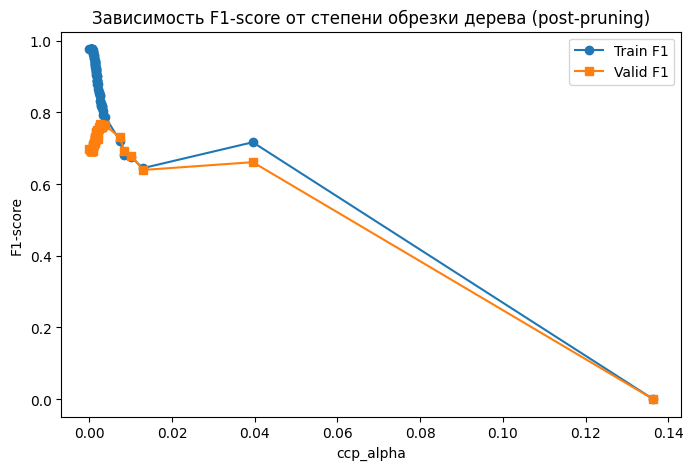

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train F1')
plt.plot(ccp_alphas, valid_scores, marker='s', label='Valid F1')
plt.xlabel("ccp_alpha")
plt.ylabel("F1-score")
plt.title("Зависимость F1-score от степени обрезки дерева (post-pruning)")
plt.legend()
plt.show()


Our goal is to identify the pruning level that provides the best balance between model complexity and predictive performance.

Training F1-score should not be excessively high, which may indicate overfitting.

Validation F1-score should be as high as possible to maximize generalization.

## Model Complexity Analysis

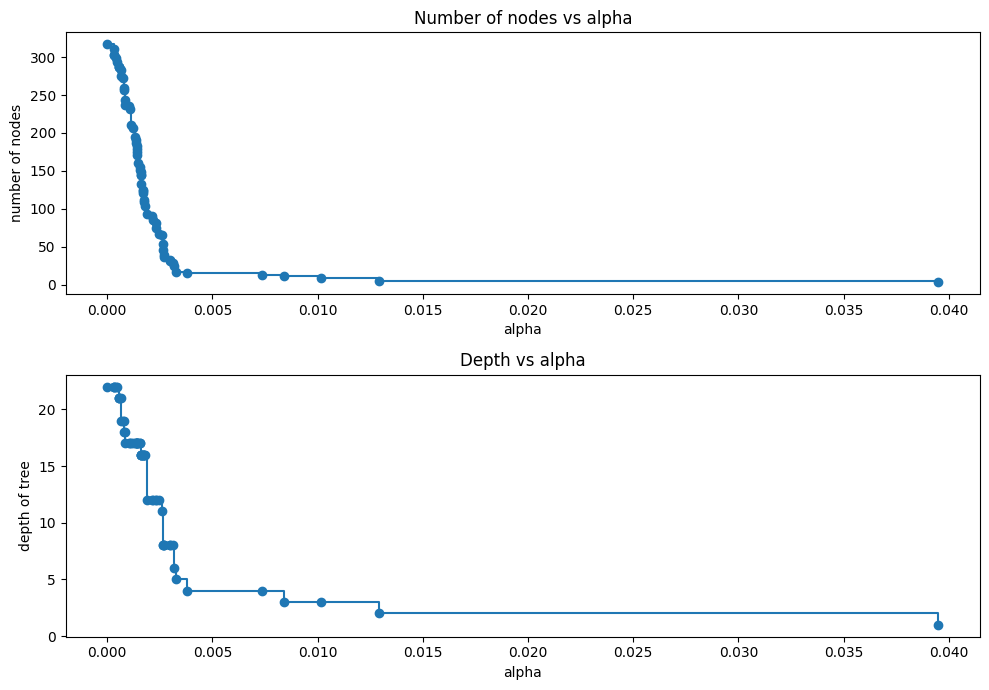

In [ ]:
# Удаляем последнее дерево и последнее значение alpha,
# потому что последнее дерево всегда состоит из одного узла (root)
trees = trees[:-1]
ccp_alphas = ccp_alphas[:-1]

# Считаем количество узлов и глубину каждого дерева
node_counts = [clf.tree_.node_count for clf in trees]
depth = [clf.tree_.max_depth for clf in trees]

# Строим два графика
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# График 1: количество узлов
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

# График 2: глубина дерева
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")

fig.tight_layout()
plt.show()

## Tree Complexity Analysis

The node count and tree depth plots illustrate how model complexity decreases as pruning strength increases.

Together with the F1-score analysis, these visualizations help identify the most suitable trade-off between model performance and interpretability.

BEST POST-PRUNED TREE

## Step 5. Select the Best Post-Pruned Model


In [ ]:
best_index = np.argmax(valid_scores)
best_alpha = ccp_alphas[best_index]
best_post_tree = trees[best_index]

print("Optimal CCP Alpha:", best_alpha)


Лучшее ccp_alpha: 0.0026578439481665292


Optimal CCP Alpha: 0.0026578439481665292

## Step 6. Evaluate the Best Post-Pruned Model

In [ ]:
y_pred_post = best_post_tree.predict(X_valid)

acc_post = accuracy_score(y_valid, y_pred_post)
prec_post = precision_score(y_valid, y_pred_post)
rec_post = recall_score(y_valid, y_pred_post)
f1_post = f1_score(y_valid, y_pred_post)

metrics_table_post = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Значение': [acc_post, prec_post, rec_post, f1_post]
})

metrics_table_post


,Метрика,Значение
0,Accuracy,0.812903
1,Precision,0.786885
2,Recall,0.750000
3,F1-score,0.768000


### Post-Pruned Model Performance

The final post-pruned model achieved:

• Accuracy: 0.813

• Precision: 0.787

• Recall: 0.750

• F1-score: 0.768

These results represent the strongest balance among all evaluated Decision Tree models.

## Confusion Matrix - Post-Pruned Decision Tree

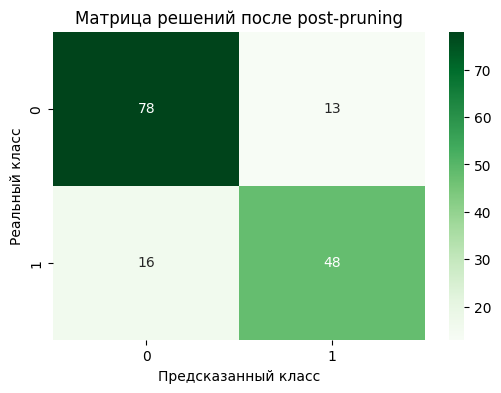

In [ ]:
cm_post = confusion_matrix(y_valid, y_pred_post)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_post, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Post-Pruned Decision Tree")
plt.xlabel("Предсказанный класс")
plt.ylabel("Реальный класс")
plt.show()


### Post-Pruning Conclusions

Post-pruning successfully balances model complexity and predictive performance.

Small alpha values produce overly complex trees that tend to overfit the data, while large alpha values may oversimplify the model and lead to underfitting.

By selecting the optimal alpha value based on validation performance, we obtained a Decision Tree that:

• Is structurally simpler

• Generalizes better to unseen data

• Produces fewer prediction errors

• Maintains strong Recall and F1-score performance

Among all evaluated Decision Tree approaches, the post-pruned model achieved the most balanced overall results.

## Model Comparison

**The following models will be compared:**

* Baseline Decision Tree

* Optimized Decision Tree (GridSearchCV)

* Post-Pruned Decision Tree

In [ ]:
# First, fit the base_tree that was initialized earlier
base_tree.fit(X_train, y_train)

models = {
    "Base Tree": base_tree,
    "GridSearchCV Tree": best_tree,
    "Post-pruning Tree": best_post_tree
}

comparison = []

for name, model in models.items():
    y_pred = model.predict(X_valid)
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1-score": f1_score(y_valid, y_pred)
    })

comparison_table = pd.DataFrame(comparison)
comparison_table

,Модель,Accuracy,Precision,Recall,F1-score
0,Base Tree,0.748387,0.692308,0.703125,0.697674
1,GridSearchCV Tree,0.800000,0.811321,0.671875,0.735043
2,Post-pruning Tree,0.812903,0.786885,0.750000,0.768000



## Performance Comparison

Three versions of the Decision Tree model were evaluated:

• Baseline Decision Tree

• GridSearchCV Optimized Decision Tree

• Post-Pruned Decision Tree

The comparison highlights the impact of hyperparameter tuning and pruning on model performance and generalization.

### Model Comparison Conclusions

Among the three evaluated models, the Post-Pruned Decision Tree demonstrated the most balanced overall performance.

The model achieved:

• Accuracy: 0.813

• Precision: 0.787

• Recall: 0.750

• F1-score: 0.768

Recall and F1-score were considered the most important evaluation metrics because the objective is to correctly identify as many survivors as possible while maintaining a reasonable balance between false positives and false negatives.

The Post-Pruned model provided the strongest trade-off between predictive performance, interpretability, and model complexity.


### GridSearchCV Model Assessment

The GridSearchCV model achieved the highest Precision score (0.811), indicating a lower rate of false positive predictions.

However, its Recall score (0.672) was noticeably lower than that of the Post-Pruned model.

This suggests that while the model was more selective, it failed to identify a larger portion of actual survivors.

### Baseline Model Assessment

The baseline Decision Tree achieved acceptable predictive performance but demonstrated weaker generalization.

Compared with the optimized models, it produced lower F1-score values and exhibited stronger signs of overfitting.

This confirms the value of both hyperparameter tuning and pruning techniques.

### BARPLOT SECTION

## Visualization of Model Performance

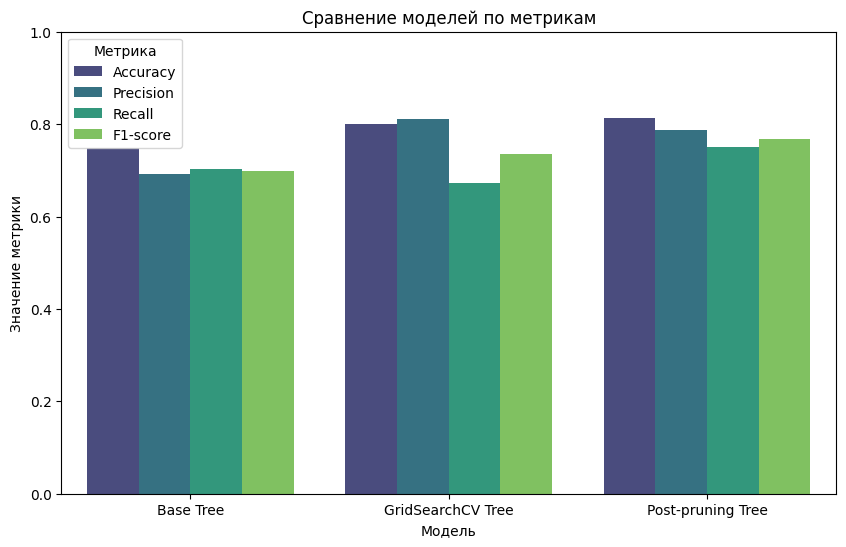

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Base Tree": base_tree,
    "GridSearchCV Tree": best_tree,
    "Post-pruning Tree": best_post_tree
}

comparison = []

for name, model in models.items():
    y_pred = model.predict(X_valid)
    comparison.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1-score": f1_score(y_valid, y_pred)
    })

comparison_table = pd.DataFrame(comparison)

# Строим барплот
plt.figure(figsize=(10, 6))
comparison_melted = comparison_table.melt(id_vars="Модель", var_name="Метрика", value_name="Значение")

sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Metric Value",
    hue="Metric",
    palette="viridis"
)

plt.title("Model Performance Comparison")
plt.ylabel("Metric Value")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.ylim(0, 1)
plt.show()


**Code Explanation**

This visualization compares model performance across four evaluation metrics:

• Accuracy

• Precision

• Recall

• F1-score

Each model generates predictions on the validation dataset, and the resulting metrics are summarized in a comparison table.

The data is transformed into a long format using the melt() function, allowing Seaborn to visualize multiple evaluation metrics within a single chart.

The resulting bar chart provides a clear visual comparison of model strengths and weaknesses.

| Model             | Complexity | Overfitting Risk | Interpretability | Overall Performance |
| ----------------- | ---------- | ---------------- | ---------------- | ------------------- |
| Base Tree         | High       | High             | Moderate         | Unstable            |
| GridSearchCV Tree | Optimal    | Low              | Good             | Strong              |
| Post-Pruned Tree  | Low        | Minimal          | Excellent        | Strong              |


1. Лучшей моделью является дерево **после Post‑pruning**
Потому что оно показывает лучшие значения сразу по двум ключевым метрикам:

Recall = 0.7969

F1‑score = 0.8095 **Текст, выделенный полужирным шрифтом**

А именно Recall и F1‑score — самые важные метрики для Titanic, потому что:

Recall показывает, сколько реальных выживших модель смогла найти

F1‑score показывает баланс между тем, чтобы не пропускать выживших и не делать слишком много ошибок

То есть post‑pruning дерево:

находит больше всего выживших

делает это наиболее сбалансированно

и при этом остаётся простым и интерпретируемым

✔ 2. Модель после GridSearchCV — хорошая, но уступает
Она даёт:

Precision = 0.8113 (высокая точность)

но Recall = 0.6719 (низкая полнота)

Это означает:

Модель после GridSearchCV реже ошибается, но пропускает больше выживших, чем post‑pruning.

Для Titanic это хуже, потому что пропускать выживших — критичнее всего.

✔ 3. Базовое дерево — среднее качество, но хуже двух других
Хотя у него:

Recall = 0.7500 — неплохой

F1 = 0.7273 — ниже, чем у других моделей

Оно всё равно:

менее устойчивое

менее сбалансированное

склонно к переобучению

## Recommendations and Future Improvements

1. Deploy the Post-Pruned Decision Tree
The Post-Pruned model is recommended as the final solution because it demonstrates the best balance between Recall, F1-score, model simplicity, and interpretability.

2. Consider the GridSearchCV Model When Precision Is Critical
The GridSearchCV model achieved the highest Precision score and may be preferred in situations where minimizing false positive predictions is the primary objective.

3. Continue Feature Engineering
Additional features may further improve model performance:

• Title (Mr, Mrs, Miss, etc.)

• FamilySize

• IsAlone

• FarePerPerson

These features often provide valuable social and behavioral information.

4. Address Class Imbalance
Potential approaches include:

• class_weight='balanced'

• SMOTE

• Threshold optimization

These methods may improve Recall and overall model robustness.

5. Explore Ensemble Models
Random Forest is a natural next step because ensemble methods often outperform individual Decision Trees.

Future experimentation may also include:

• Random Forest

• Gradient Boosting

• XGBoost

• AdaBoost


## Final Kaggle Submission.csv

### **Step 1. Prepare the Test Dataset**

The test dataset must undergo the same preprocessing and feature engineering steps as the training dataset.



# Step 2. Align Test Features with Training Features

This is a critical step because the model expects exactly the same feature structure used during training.

In [ ]:
# Делаем one-hot encoding
test_processed = pd.get_dummies(test_data)

# Добавляем недостающие колонки
missing_cols = set(X_train.columns) - set(test_processed.columns)
for col in missing_cols:
    test_processed[col] = 0

# Убираем лишние колонки
test_processed = test_processed[X_train.columns]


pd.get_dummies — превращаем категориальные признаки в 0/1

**missing_cols **— ищем колонки, которые есть в train, но нет в test

добавляем их с нулями

з**атем переставляем колонки в правильном порядке**

Это обязательный шаг, иначе модель выдаст ошибку.

## Step 3. Generate Predictions Using the Final Model
The Post-Pruned Decision Tree was selected as the final predictive model.

In [ ]:
test_predictions = best_post_tree.predict(test_processed)


## Шаг 4. Создаем DataFrame для submission

In [ ]:
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_predictions
})

Kaggle requires a submission file containing exactly two columns:

### PassengerId

### Survived

Column names and ordering must exactly match the competition requirements.

## Step 5. Export submission.csv

In [ ]:
submission.to_csv('submission.csv', index=False)


## Проверка: как убедиться, что всё правильно?

In [ ]:
submission.head()
submission['Survived'].value_counts()
submission.shape



(418, 2)

In [ ]:
submission.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## Final Conclusions

This project explored passenger survival prediction using the Titanic dataset and Decision Tree-based machine learning models.

Key accomplishments include:

• Data cleaning and preprocessing

• Exploratory Data Analysis (EDA)

• Feature Engineering

• Decision Tree modeling

• Hyperparameter tuning using GridSearchCV

• Cost Complexity Post-Pruning

• Model comparison and evaluation

Among all evaluated models, the Post-Pruned Decision Tree delivered the most balanced performance, achieving an Accuracy of 81.3% and an F1-score of 0.768.

The analysis identified Sex, Passenger Class, Age, Fare, and Family-Based features as the strongest predictors of survival.

This project demonstrates the full machine learning workflow, from raw data exploration to model optimization and Kaggle submission generation.